## Now we will impliment our own liner regression model

In [50]:
from sklearn.datasets import load_diabetes



In [51]:
import numpy as np 
import pandas as pd

In [52]:
X =load_diabetes(return_X_y=True)

In [53]:
X

(array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59.

In [54]:
data = pd.DataFrame(X[0])
type(data)

pandas.DataFrame

In [55]:
diabeties = pd.DataFrame(X[1],columns=['diabeties'])

In [56]:
type(diabeties)

pandas.DataFrame

In [57]:
X=data
y = diabeties

In [58]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [59]:
X_train.shape

(309, 10)

In [60]:
X_test.shape

(133, 10)

In [61]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
model = lr.fit(X_train,Y_train)

In [62]:
X_train.shape

(309, 10)

In [63]:
out = model.predict(X_test)


In [64]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


In [65]:
print(r2_score(Y_test,out))

0.4772897164322616


In [66]:
print(mean_absolute_error(Y_test,out))

41.91937845679274


In [67]:
print(mean_squared_error(Y_test,out))

2821.7509810013116


Then your dataframe contains only the actual features:

$$
X=
\begin{bmatrix}
x_{11} & x_{12} & x_{13}\\
x_{21} & x_{22} & x_{23}\\
\vdots & \vdots & \vdots
\end{bmatrix}
$$

But the linear regression equation is

$$
\hat{y}
=
\beta_0
+
\beta_1x_1
+
\beta_2x_2
+
\cdots
+
\beta_mx_m
$$

Notice the term $\beta_0$.

This is the **intercept (bias)**.

### The final formulae was
$$
β=(X^TX)^{-1}X^TY
$$


$$
X
=
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1m} \\
1 & x_{21} & x_{22} & \cdots & x_{2m} \\
1 & x_{31} & x_{32} & \cdots & x_{3m} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{n1} & x_{n2} & \cdots & x_{nm}
\end{bmatrix}
$$
so we will have to convert the feature matrix like this

## Making our own LR class

In [68]:
class MeraLR:
    def __init__(self):
        self.coef = None
        self.intercept = None
    def fit(self,X_train,Y_test):
        X_b= np.insert(X_train,0,1,axis=1)
        betas = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y_train)
        self.intercept = betas [0]
        self.coef = betas[1:]
    def predict(self,X_test):
        return X_test.dot(self.coef)+self.intercept


In [69]:
ml= MeraLR()
ml.fit(X_train,Y_train)
pred = ml.predict(X_test)
from sklearn.metrics import r2_score
print(pred)



              0
287  138.469700
211  181.100523
72   125.344009
321  292.759773
73   123.883053
..          ...
238  202.997787
26    92.101004
7    122.288768
401   80.808670
108  233.218705

[133 rows x 1 columns]


In [70]:
pred

,0
287,138.469700
211,181.100523
72,125.344009
321,292.759773
73,123.883053
...,...
238,202.997787
26,92.101004
7,122.288768
401,80.808670


In [71]:
Y_test

,diabeties
287,219.0
211,70.0
72,202.0
321,230.0
73,111.0
...,...
238,257.0
26,137.0
7,63.0
401,93.0


In [72]:

residual=pred.values-Y_test.values

In [73]:
residual

array([[ -80.53029969],
       [ 111.10052342],
       [ -76.65599096],
       [  62.75977277],
       [  12.8830531 ],
       [   7.89830434],
       [  15.26463123],
       [ -94.23830682],
       [  -9.01450294],
       [  13.15960992],
       [   0.4855284 ],
       [ -85.86764892],
       [ -41.59257498],
       [ -90.86102646],
       [ -37.2188158 ],
       [  64.00472765],
       [ -80.70210028],
       [ -11.47092339],
       [  29.66656381],
       [ -55.50014366],
       [-106.76328683],
       [  24.00656925],
       [ -57.34891541],
       [ -45.07766573],
       [  26.81266751],
       [  44.81022205],
       [ -71.06864294],
       [ 107.72924276],
       [  -1.37079171],
       [   1.26566599],
       [  38.14743952],
       [ -21.64934995],
       [  37.72125745],
       [  20.04205666],
       [  -7.76200103],
       [ -43.48451137],
       [  79.83265708],
       [  33.75339206],
       [ -26.32049694],
       [  -4.42436599],
       [  24.55421321],
       [  -0.724

In [74]:
type(X_test)

pandas.DataFrame

In [75]:
type(pred)

pandas.DataFrame

In [76]:
out = r2_score(Y_test,pred)
print(out)

0.4772897164322608


# Assumptions of Linear regression
- The Data should be linear
- There should not be multicolinearity
- 


In [77]:
# How to check the multicolinarity in the dataset

In [78]:
df = pd.read_csv('/run/media/darshchouhan/New Volume/ML_Algorithm/DATA SETS/concrete_data.csv')

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [80]:
import matplotlib.pyplot as plt

In [81]:
X=df.drop('Strength',axis=1)
Y=df['Strength']

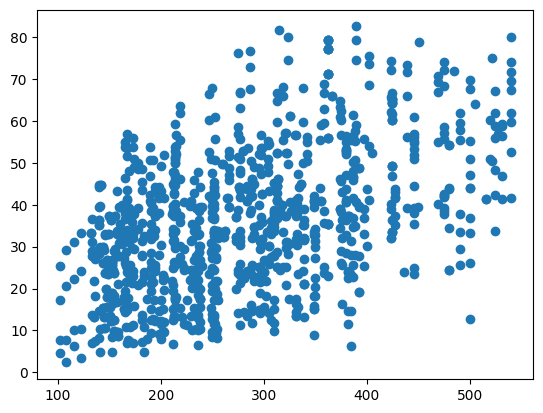

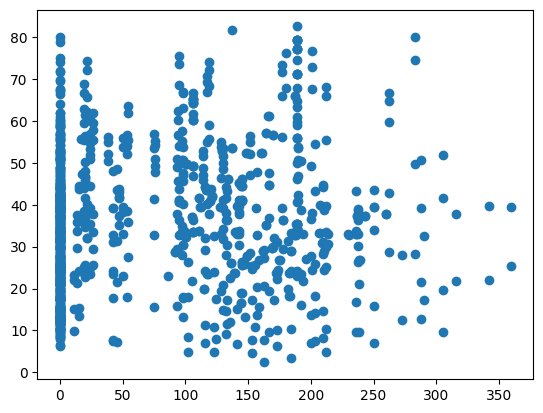

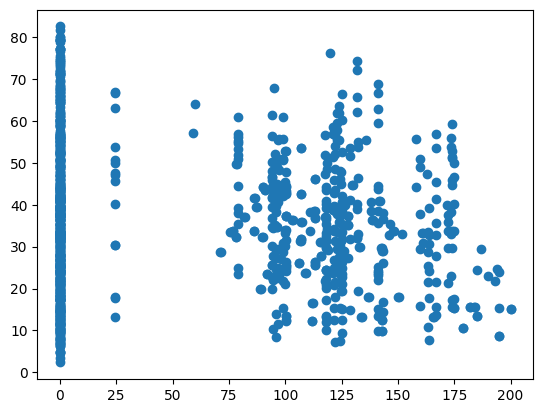

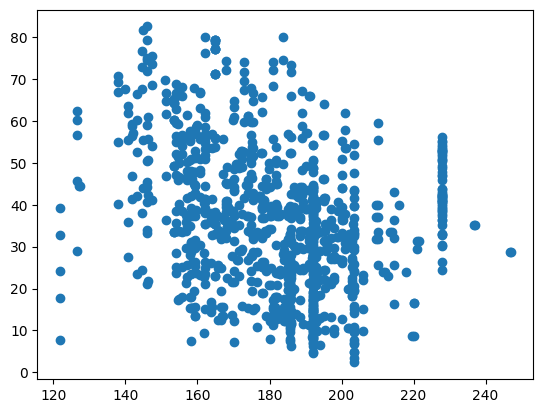

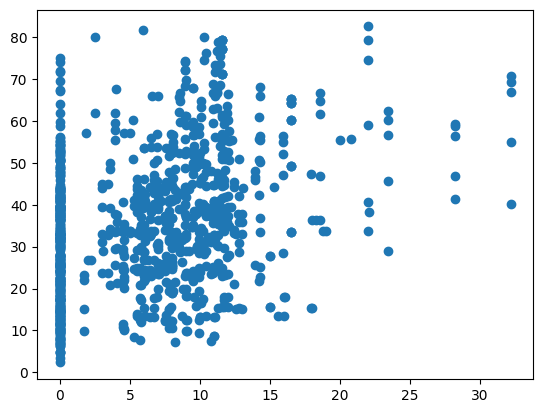

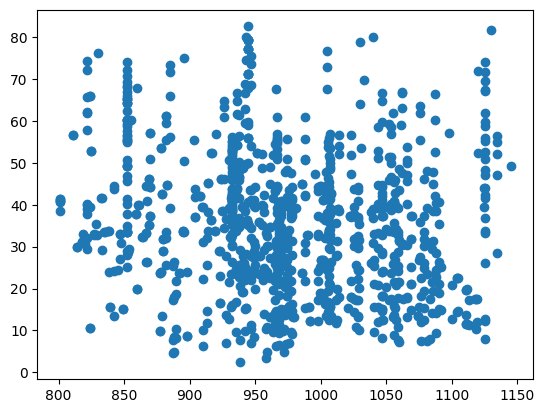

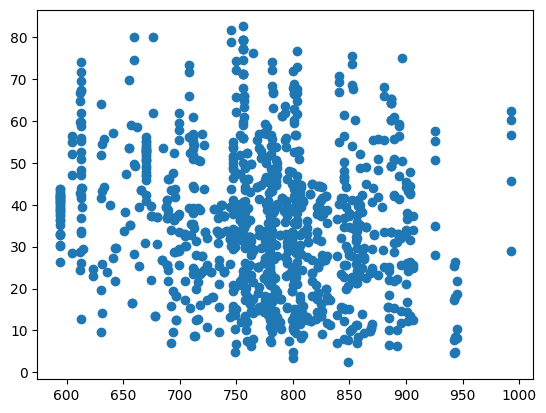

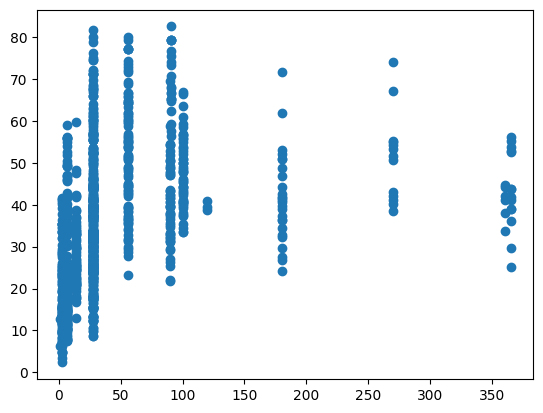

In [82]:
#check of the linearity
for col in X.columns:
    plt.figure()
    plt.scatter(df[col],Y)

   

In [83]:
df.corr()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
Cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
Blast Furnace Slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
Fly Ash,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
Water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
Superplasticizer,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079
Coarse Aggregate,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935
Fine Aggregate,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241
Age,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873
Strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000


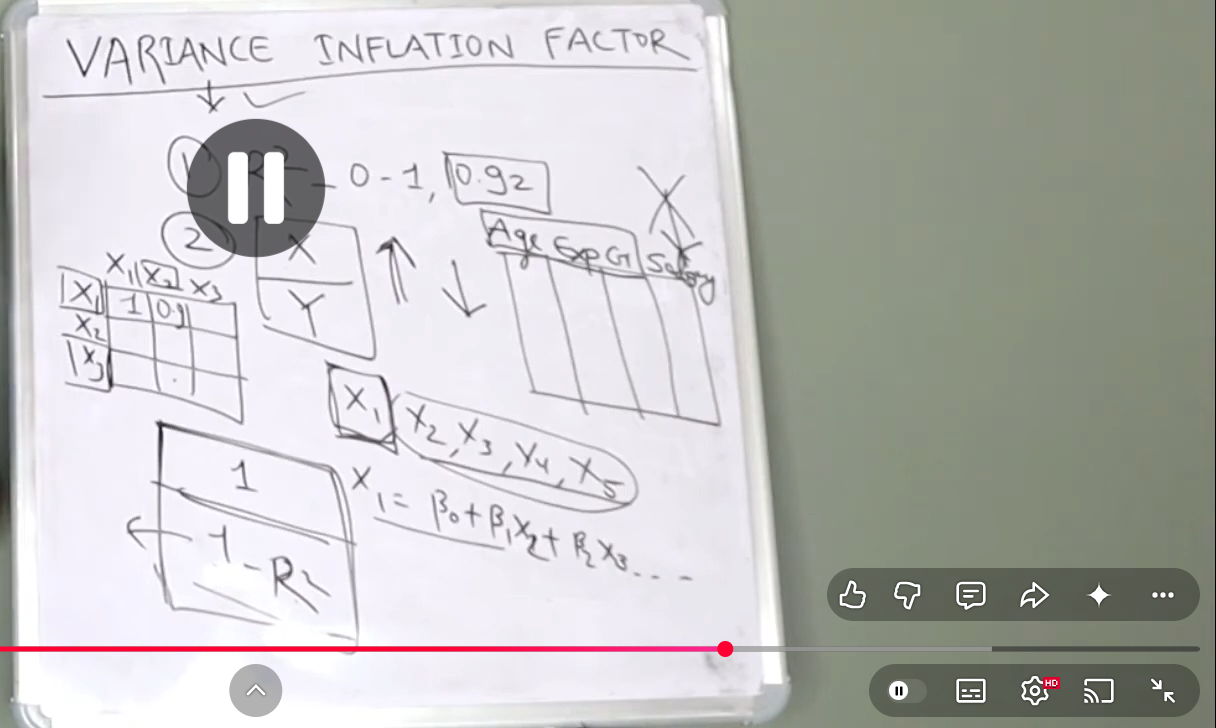

## Multicolinearity

In [84]:
new_df = df.drop('Strength',axis = 1)

In [85]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []
for i in range(new_df.shape[1]):
    vif.append(variance_inflation_factor(new_df.values, i))

vif = pd.DataFrame({
    "Feature": new_df.columns,
    "VIF": vif
})

vif

,Feature,VIF
0,Cement,15.456717
1,Blast Furnace Slag,3.329127
2,Fly Ash,4.147833
3,Water,82.157569
4,Superplasticizer,5.471094
5,Coarse Aggregate,84.955779
6,Fine Aggregate,72.790995
7,Age,1.699459


## Normal Recidual

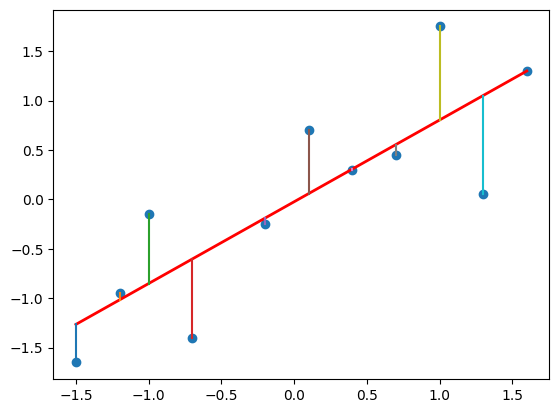

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample data
X = np.array([-1.5,-1.2,-1.0,-0.7,-0.2,0.1,0.4,0.7,1.0,1.3,1.6]).reshape(-1,1)
y = np.array([-1.65,-0.95,-0.15,-1.4,-0.25,0.7,0.3,0.45,1.75,0.05,1.3])

# Train model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Scatter plot
plt.scatter(X, y)

# Regression line
plt.plot(X, y_pred, color='red', linewidth=2)

# Residual lines
for i in range(len(X)):
    plt.plot(
        [X[i,0], X[i,0]],
        [y[i], y_pred[i]])

### The recidual is the difference between the the y and the preducted value and that difference  should be normal  

In [87]:
import matplotlib.pyplot as plt

In [88]:
import seaborn as sns

In [89]:
residual = pd.DataFrame(residual)

<Axes: ylabel='Count'>

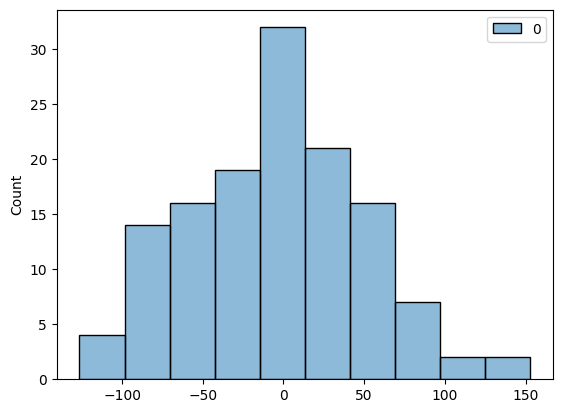

In [90]:
import seaborn as sns
sns.histplot(residual)

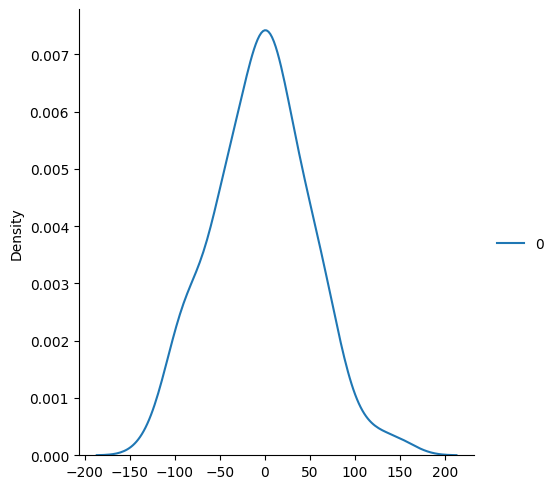

In [91]:
sns.displot(residual,kind='kde')

In [92]:
residual

,0
0,-80.530300
1,111.100523
2,-76.655991
3,62.759773
4,12.883053
...,...
128,-54.002213
129,-44.898996
130,59.288768
131,-12.191330


/tmp/ipykernel_11222/2399703271.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual,ax= axis[1])


<Axes: ylabel='Density'>

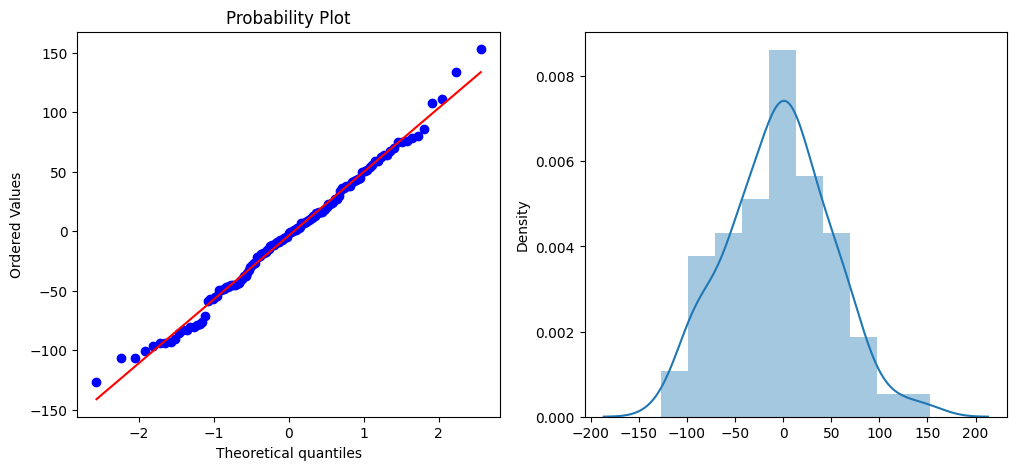

In [103]:
import scipy as sp
fig,axis = plt.subplots(1,2,figsize=(12,5))
sp.stats.probplot(residual.iloc[:,0], plot=axis[0])
sns.distplot(residual,ax= axis[1])

## Homoscedasticity

- Having the same scatter

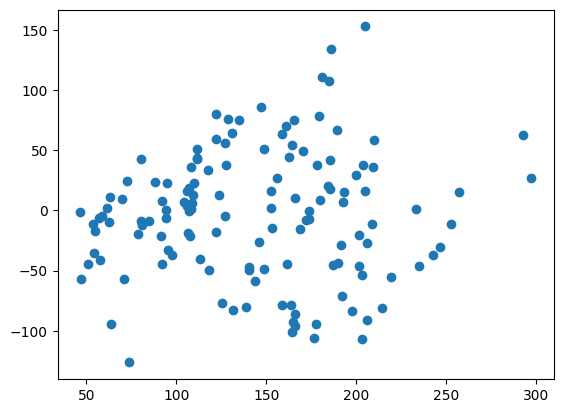

In [107]:
plt.scatter(pred,residual)

## No Auto-Correlation of Error

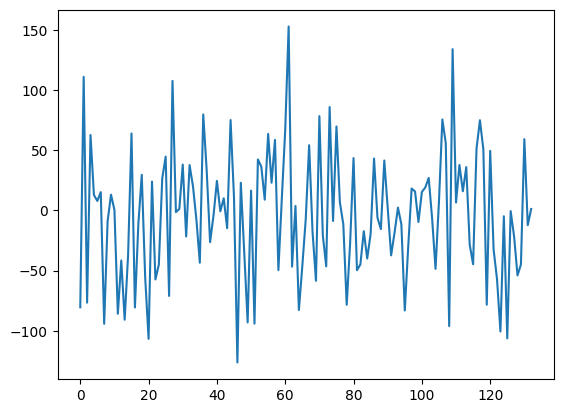

In [108]:
plt.plot(residual)